## EDA2 - 对预处理后的数据进行探索性数据分析

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from datetime import datetime

# 设置中文字体和绘图样式
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings('ignore')

## 1. 数据加载

In [29]:
# 加载数据
file_path = "../data/processed/processed_data.csv"
df = pd.read_csv(file_path, encoding='utf-8-sig')

print(f"数据形状: {df.shape}")
print(f"时间范围: {df['日期'].min()} 到 {df['日期'].max()}")
print(f"总记录数: {len(df)}")
print(f"总天数: {df['日期'].nunique()}")

# 中文列名映射到英文
column_mapping = {
    '日期': 'date',
    '时段': 'time_period',
    '年': 'year',
    '月': 'month',
    '日': 'day',
    '星期': 'weekday',
    '是否周末': 'is_weekend',
    '季度': 'quarter',
    '小时': 'hour',
    '是否高峰时段': 'is_peak_hour',
    '是否夜间': 'is_night',
    '系统负荷-实时': 'system_load_real_time',
    '新能源出力-实时': 'new_power_real_time',
    '非市场化机组出力-实时': 'non_market_unit_power_real_time',
    '联络线计划-实时': 'tie_line_plan_real_time',
    '平均出清价格-实时（元/MWh）': 'clearing_price_real_time',
    '光伏出力-实时': 'solar_power_real_time',
    '风电出力-实时': 'wind_power_real_time',
    '水电出力-实时': 'hydro_power_real_time'
}
    
# 创建英文列名的副本
df_en = df.rename(columns=column_mapping)

# 显示数据基本信息
df.info()

数据形状: (7272, 333)
时间范围: 2024-05-28 到 2025-03-26
总记录数: 7272
总天数: 303
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7272 entries, 0 to 7271
Columns: 333 entries, 日期 to 平均出清价格-实时（元/MWh）
dtypes: float64(323), int64(8), object(2)
memory usage: 18.5+ MB


## 2. 数据质量检查

In [4]:
# 检查缺失值
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

print("=== 缺失值统计 ===")
missing_info = pd.DataFrame({
    '缺失数量': missing_data,
    '缺失比例(%)': missing_percentage.round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)

if len(missing_info) > 0:
    display(missing_info)
else:
    print("✓ 无缺失值")

# 检查重复值
duplicate_count = df.duplicated().sum()
print(f"\n重复记录数: {duplicate_count}")

# 检查数据类型
print("\n=== 数据类型分布 ===")
print(df.dtypes.value_counts())


=== 缺失值统计 ===
✓ 无缺失值

重复记录数: 0

=== 数据类型分布 ===
float64    323
int64        8
object       2
Name: count, dtype: int64


In [12]:
# 数值变量的描述性统计
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("=== 数值变量描述性统计 ===")

# 过滤掉时间特征列
value_cols = [col for col in numeric_cols if col not in ['year', 'month', 'day', 'weekday', 'is_weekend', 'quarter', 'hour', 'is_peak_hour', 'is_night']]

descriptive_stats = df[value_cols].describe().T
descriptive_stats['变异系数'] = descriptive_stats['std'] / descriptive_stats['mean']
descriptive_stats['缺失值数量'] = df[value_cols].isnull().sum()

display(descriptive_stats.round(2))

=== 数值变量描述性统计 ===


,count,mean,std,min,25%,50%,75%,max,变异系数,缺失值数量
孝感市-温度-源2-预测,7272.0,17.78,10.40,-4.9,8.50,18.40,27.20,37.20,0.58,0
孝感市-温度-源3-预测,7272.0,17.76,10.40,-4.9,8.50,18.40,27.20,37.10,0.59,0
孝感市-温度-源4-预测,7272.0,18.17,9.64,-3.7,9.50,18.70,26.50,37.50,0.53,0
孝感市-温度-源5-预测,7272.0,17.30,10.37,-3.2,7.60,18.00,27.30,36.80,0.60,0
孝感市-温度-源5-实际,7272.0,17.61,10.35,-5.2,8.50,18.40,26.90,37.10,0.59,0
...,...,...,...,...,...,...,...,...,...,...
光伏出力-实时,7272.0,2555.86,3762.10,0.0,0.00,16.76,4465.07,14283.42,1.47,0
水电出力-实时,7272.0,13688.86,7281.25,0.0,8801.93,10210.94,16141.27,34487.36,0.53,0
联络线计划-实时,7272.0,-5122.57,3716.27,-17078.0,-6836.75,-4099.50,-2397.50,1014.00,-0.73,0
非市场化机组出力-实时,7272.0,18010.90,7716.15,0.0,12210.29,15404.74,20720.39,41470.74,0.43,0


## 3. 时间序列分析

In [15]:
# 创建时间序列数据（按日期聚合）
daily_data = df_en.groupby('date').agg({
    'system_load_real_time': 'mean',
    'wind_power_real_time': 'mean',
    'solar_power_real_time': 'mean',
    'clearing_price_real_time': 'mean',
    'non_market_unit_power_real_time': 'mean',
}).reset_index()

print("每日聚合数据形状:", daily_data.shape)

每日聚合数据形状: (303, 6)


## 4. 电价特征分析

### 4.1 电价波动分析


各星期实时出清电价统计信息：
  Weekday Avg Price Max Price Min Price Price Std Dev
   Monday    354.86    435.65    254.75         47.84
  Tuesday    354.64    440.29    213.41         63.88
Wednesday    347.11    443.24    219.23         63.40
 Thursday    357.43    441.01    254.50         53.48
   Friday    359.78    461.24    243.03         60.04
 Saturday    350.48    450.33    218.61         62.48
   Sunday    324.95    403.23    191.22         66.06


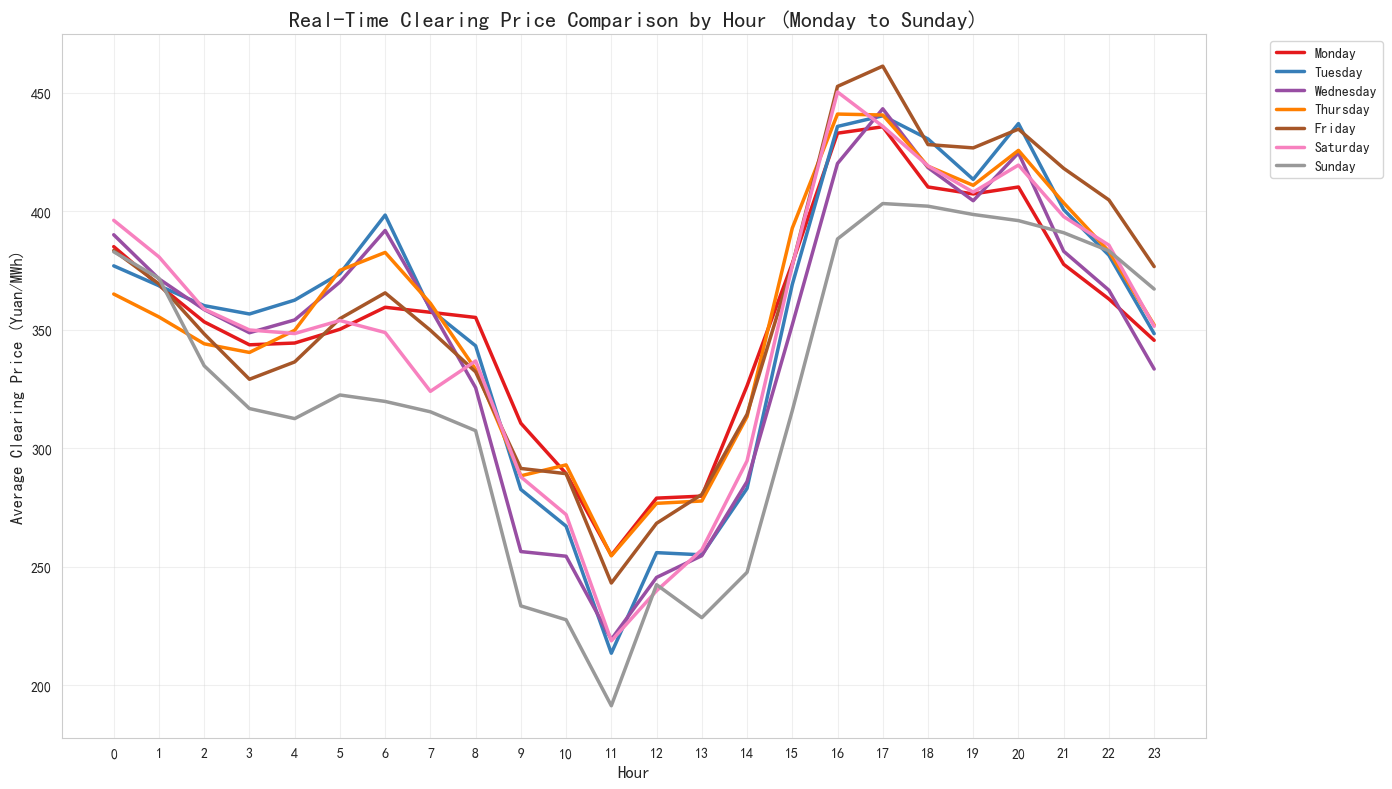

In [16]:
# 创建所有星期叠加对比图
plt.figure(figsize=(14, 8))

# 定义星期名称
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 为每个星期绘制曲线
colors = plt.cm.Set1(np.linspace(0, 1, 7))
for weekday in range(1, 8):
    weekday_data = df_en[df_en['weekday'] == weekday]
    hourly_prices = weekday_data.groupby('hour')['clearing_price_real_time'].mean()
    
    plt.plot(hourly_prices.index, hourly_prices.values, 
             label=weekday_names[weekday-1], linewidth=2.5, color=colors[weekday-1])

plt.title('Real-Time Clearing Price Comparison by Hour (Monday to Sunday)', fontsize=16, fontweight='bold')
plt.xlabel('Hour', fontsize=12)  
plt.ylabel('Average Clearing Price (Yuan/MWh)', fontsize=12)  
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))

# 添加统计表格
weekday_stats = []
for weekday in range(1, 8):
    weekday_data = df_en[df_en['weekday'] == weekday]
    hourly_prices = weekday_data.groupby('hour')['clearing_price_real_time'].mean()
    
    stats = {
        'Weekday': weekday_names[weekday-1], 
        'Avg Price': f'{hourly_prices.mean():.2f}',  
        'Max Price': f'{hourly_prices.max():.2f}',  
        'Min Price': f'{hourly_prices.min():.2f}', 
        'Price Std Dev': f'{hourly_prices.std():.2f}'  
    }
    weekday_stats.append(stats)

stats_df = pd.DataFrame(weekday_stats)
print("\n各星期实时出清电价统计信息：")
print(stats_df.to_string(index=False))

plt.tight_layout()
plt.show()

### 4.2 电价滞后项分析

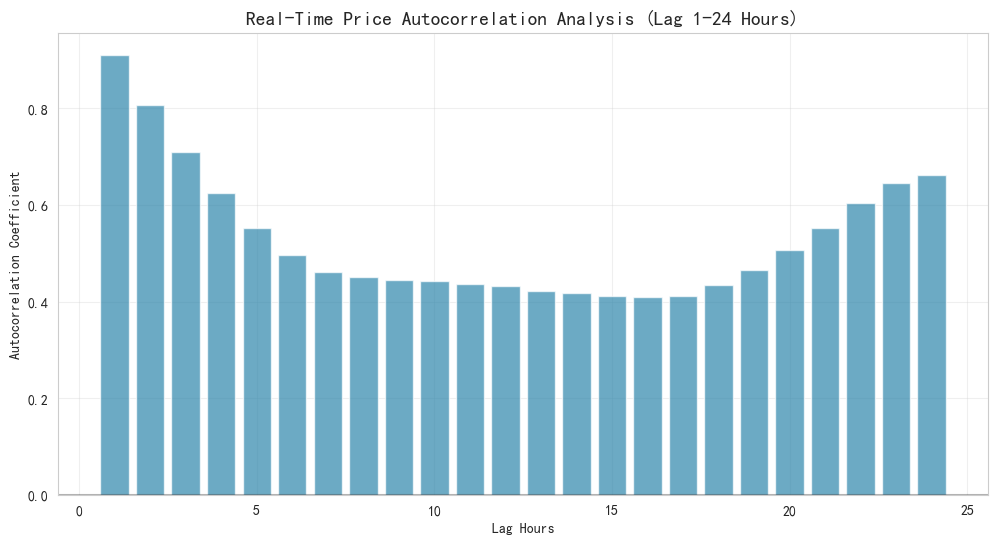


Significant autocorrelation lag features (|correlation| > 0.5):
Lag 1 hours: 0.911
Lag 2 hours: 0.807
Lag 3 hours: 0.709
Lag 4 hours: 0.625
Lag 5 hours: 0.552
Lag 20 hours: 0.507
Lag 21 hours: 0.552
Lag 22 hours: 0.603
Lag 23 hours: 0.646
Lag 24 hours: 0.663


In [17]:
# 创建滞后特征
price_data = df_en['clearing_price_real_time'].dropna()

# 计算不同滞后期的自相关性
lags = range(1, 25)  # 1-24小时滞后
autocorrelations = [price_data.autocorr(lag=lag) for lag in lags]

plt.figure(figsize=(12, 6))
plt.bar(lags, autocorrelations, color='#2E86AB', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Real-Time Price Autocorrelation Analysis (Lag 1-24 Hours)', fontsize=14, fontweight='bold')
plt.xlabel('Lag Hours')
plt.ylabel('Autocorrelation Coefficient')
plt.grid(True, alpha=0.3)
plt.show()

# 显示最重要的滞后特征
significant_lags = [(lag, corr) for lag, corr in zip(lags, autocorrelations) if abs(corr) > 0.5]
print("\nSignificant autocorrelation lag features (|correlation| > 0.5):")
for lag, corr in significant_lags:
    print(f"Lag {lag} hours: {corr:.3f}")

### 4.3 电价季节性分析

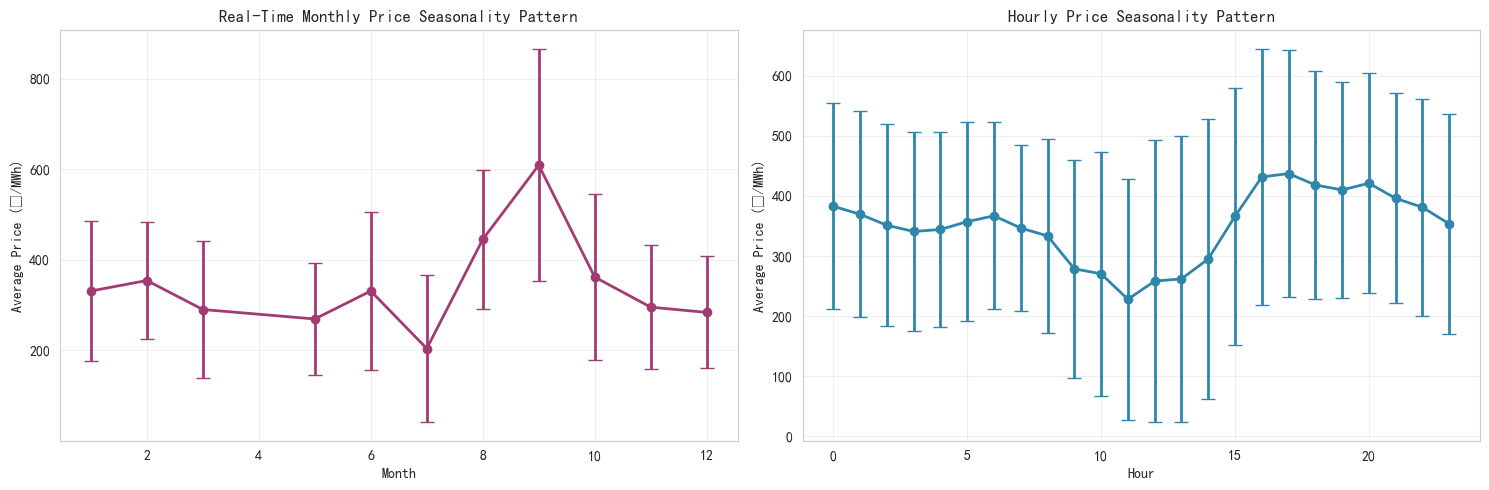

In [18]:
# 月度季节性分析
monthly_seasonality = df_en.groupby('month')['clearing_price_real_time'].agg(['mean', 'std'])

# 小时季节性分析
hourly_seasonality = df_en.groupby('hour')['clearing_price_real_time'].agg(['mean', 'std'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 月度季节性
axes[0].errorbar(monthly_seasonality.index, monthly_seasonality['mean'], 
                    yerr=monthly_seasonality['std'], fmt='o-', color='#A23B72', 
                    capsize=5, linewidth=2)
axes[0].set_title('Real-Time Monthly Price Seasonality Pattern', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Price (¥/MWh)')
axes[0].grid(True, alpha=0.3)

# 小时季节性
axes[1].errorbar(hourly_seasonality.index, hourly_seasonality['mean'], 
                    yerr=hourly_seasonality['std'], fmt='o-', color='#2E86AB', 
                    capsize=5, linewidth=2)
axes[1].set_title('Hourly Price Seasonality Pattern', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Average Price (¥/MWh)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4 电价与负荷的关系分析

<Figure size 1200x800 with 0 Axes>

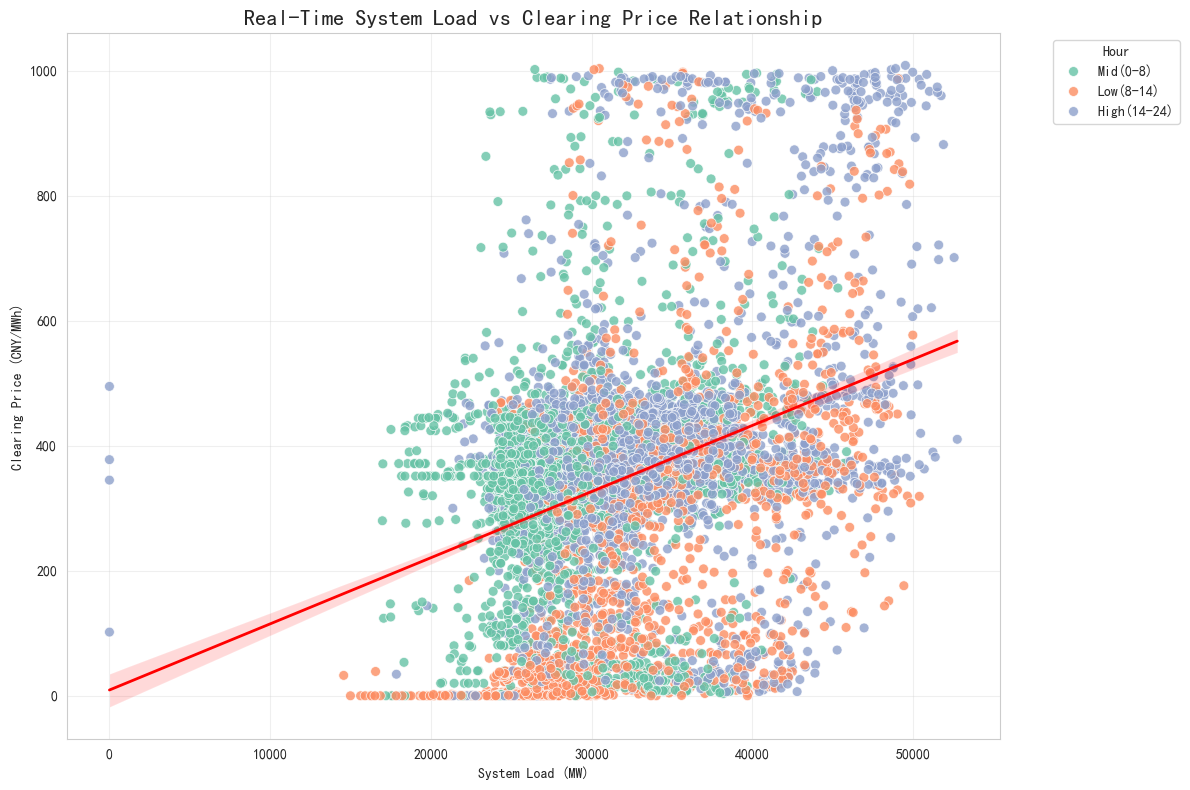

In [20]:
# 价格与负荷的关系分析
plt.figure(figsize=(12, 8))

# 将散点依据低、中、高峰进行划分
df_en['time_period'] = pd.cut(df_en['hour'], 
                               bins=[0, 8, 14, 24],  # 自定义区间
                               labels=['Mid(0-8)', 'Low(8-14)', 'High(14-24)'],
                               include_lowest=True)

plt.figure(figsize=(12, 8))
scatter_plot = sns.scatterplot(data=df_en, x='system_load_real_time', y='clearing_price_real_time', 
                               hue='time_period', palette='Set2', alpha=0.8, s=50)

# 添加趋势线
sns.regplot(data=df_en, x='system_load_real_time', y='clearing_price_real_time', 
            scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('Real-Time System Load vs Clearing Price Relationship', fontsize=16, fontweight='bold')
plt.xlabel('System Load (MW)')
plt.ylabel('Clearing Price (CNY/MWh)')
plt.legend(title='Hour', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

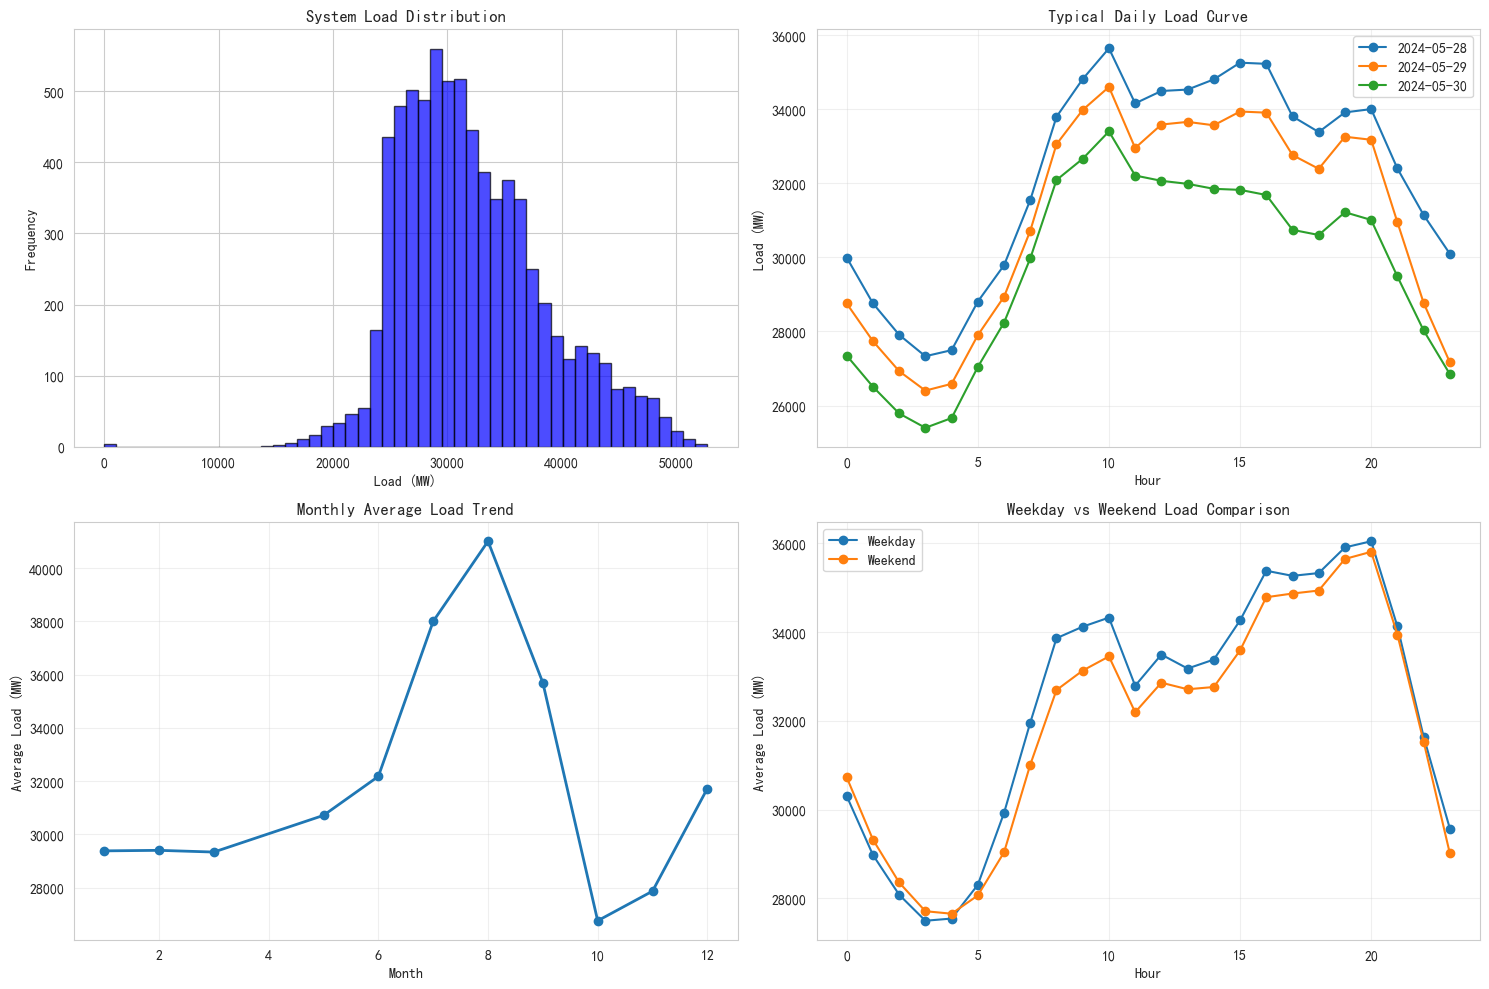

In [22]:
# 负荷模式分析
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 负荷分布
axes[0,0].hist(df_en['system_load_real_time'].dropna(), bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0,0].set_title('System Load Distribution')
axes[0,0].set_xlabel('Load (MW)')
axes[0,0].set_ylabel('Frequency')

# 典型日负荷曲线（取一周数据为例）
df_en['date'] = pd.to_datetime(df_en['date'])
week_data = df_en[df_en['date'] <= df_en['date'].min() + pd.Timedelta(days=7)]
hourly_load = week_data.groupby(['date', 'hour'])['system_load_real_time'].mean().reset_index()

for date in hourly_load['date'].unique()[:3]:  # 显示前3天的曲线
    day_data = hourly_load[hourly_load['date'] == date]
    axes[0,1].plot(day_data['hour'], day_data['system_load_real_time'], 
                   label=date.strftime('%Y-%m-%d'), marker='o')

axes[0,1].set_title('Typical Daily Load Curve')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Load (MW)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 负荷季节性分析（按月）
monthly_load = df_en.groupby('month')['system_load_real_time'].mean()
axes[1,0].plot(monthly_load.index, monthly_load.values, marker='o', linewidth=2)
axes[1,0].set_title('Monthly Average Load Trend')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Average Load (MW)')
axes[1,0].grid(True, alpha=0.3)

# 工作日 vs 周末负荷对比
weekend_load = df_en.groupby(['is_weekend', 'hour'])['system_load_real_time'].mean().reset_index()

for weekend in [0, 1]:
    data = weekend_load[weekend_load['is_weekend'] == weekend]
    label = 'Weekday' if weekend == 0 else 'Weekend'
    axes[1,1].plot(data['hour'], data['system_load_real_time'], label=label, marker='o')

axes[1,1].set_title('Weekday vs Weekend Load Comparison')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Average Load (MW)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 新能源出力分析

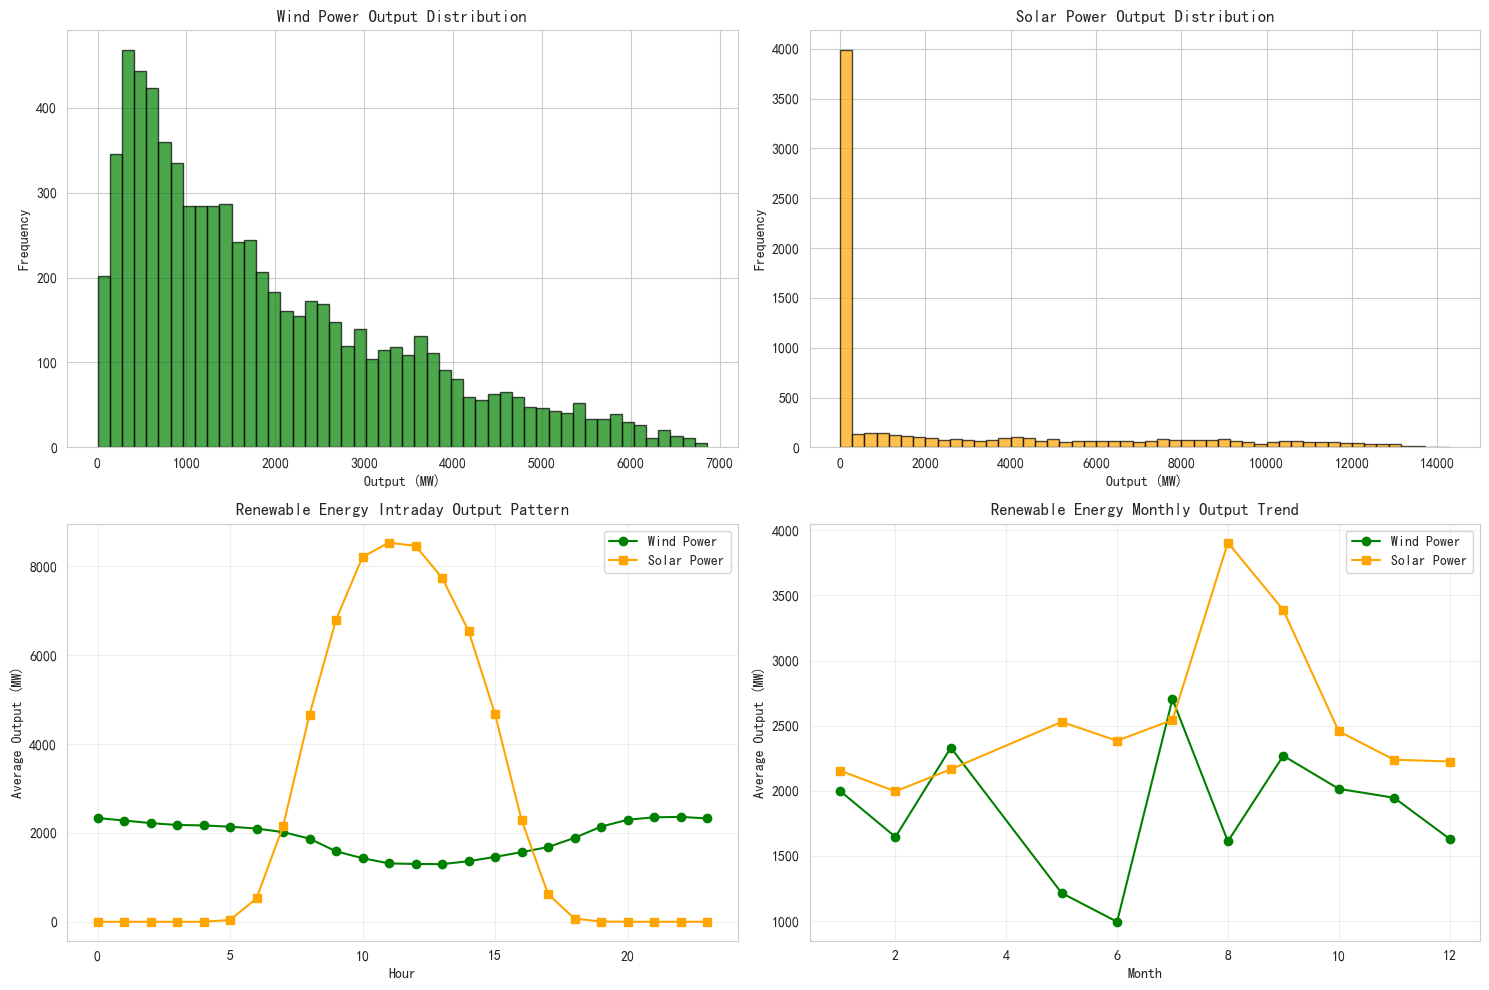

In [23]:
# 新能源出力特征分析
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 风电出力分布
axes[0,0].hist(df_en['wind_power_real_time'].dropna(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0,0].set_title('Wind Power Output Distribution')
axes[0,0].set_xlabel('Output (MW)')
axes[0,0].set_ylabel('Frequency')

# 光伏出力分布
axes[0,1].hist(df_en['solar_power_real_time'].dropna(), bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[0,1].set_title('Solar Power Output Distribution')
axes[0,1].set_xlabel('Output (MW)')
axes[0,1].set_ylabel('Frequency')

# 新能源日内变化模式
hourly_wind = df_en.groupby('hour')['wind_power_real_time'].mean()
hourly_solar = df_en.groupby('hour')['solar_power_real_time'].mean()

axes[1,0].plot(hourly_wind.index, hourly_wind.values, label='Wind Power', color='green', marker='o')
axes[1,0].plot(hourly_solar.index, hourly_solar.values, label='Solar Power', color='orange', marker='s')
axes[1,0].set_title('Renewable Energy Intraday Output Pattern')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Average Output (MW)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 新能源季节性变化
monthly_wind = df_en.groupby('month')['wind_power_real_time'].mean()
monthly_solar = df_en.groupby('month')['solar_power_real_time'].mean()

axes[1,1].plot(monthly_wind.index, monthly_wind.values, label='Wind Power', color='green', marker='o')
axes[1,1].plot(monthly_solar.index, monthly_solar.values, label='Solar Power', color='orange', marker='s')
axes[1,1].set_title('Renewable Energy Monthly Output Trend')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Average Output (MW)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 非市场化机组出力与水电出力

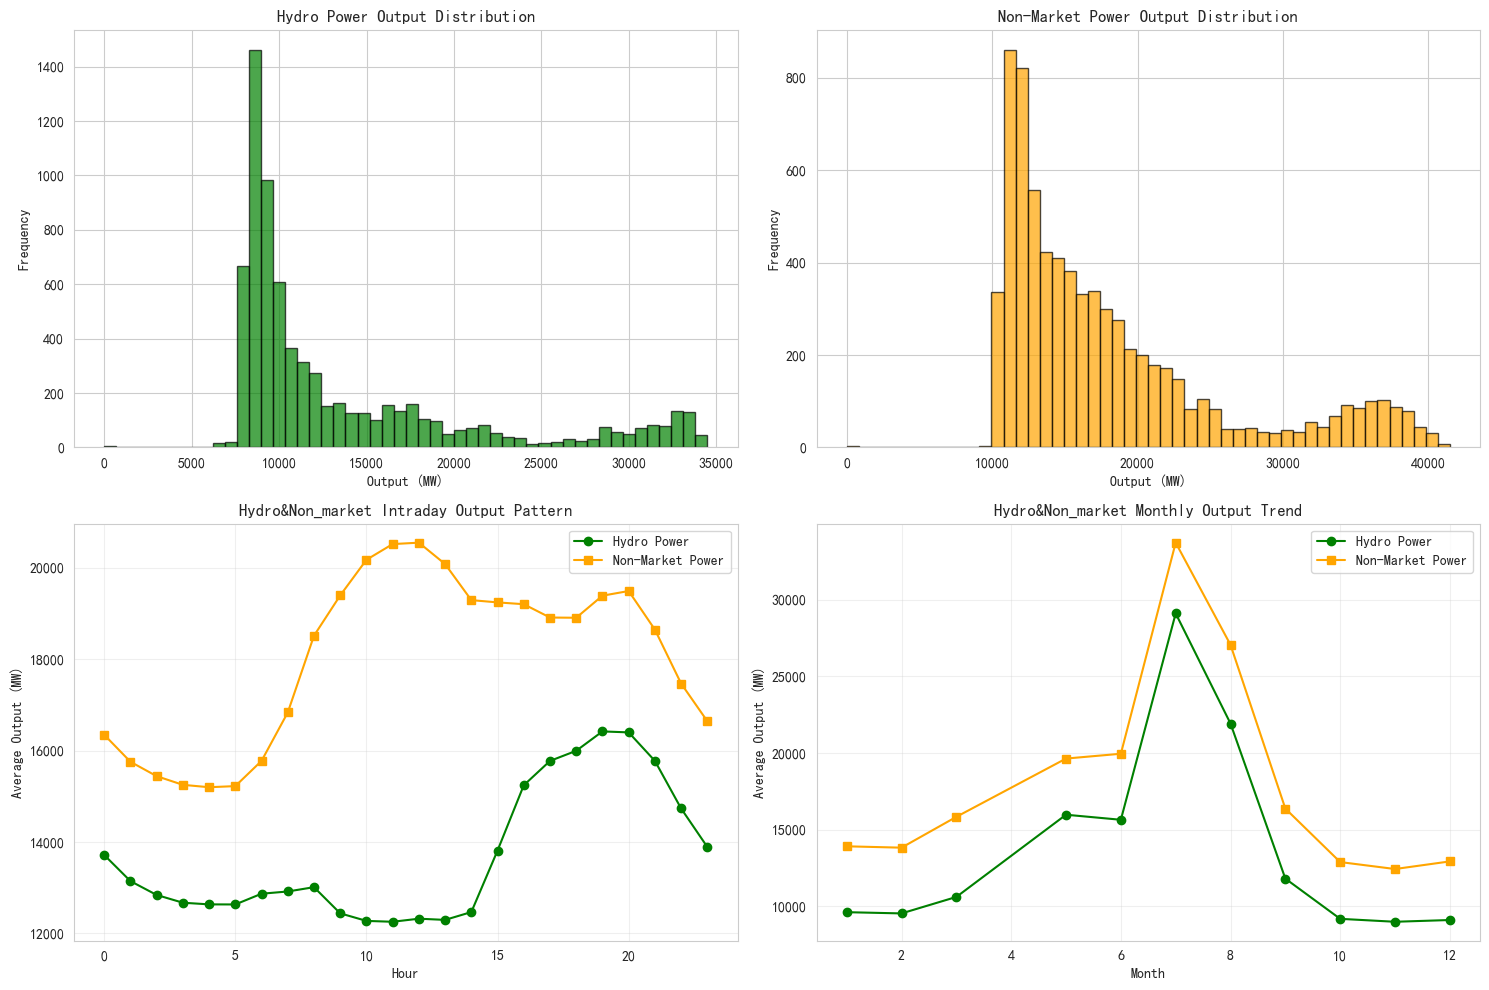

In [26]:
# 新能源出力特征分析
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 水电出力分布
axes[0,0].hist(df_en['hydro_power_real_time'].dropna(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0,0].set_title('Hydro Power Output Distribution')
axes[0,0].set_xlabel('Output (MW)')
axes[0,0].set_ylabel('Frequency')

# 非市场化机组出力分布
axes[0,1].hist(df_en['non_market_unit_power_real_time'].dropna(), bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[0,1].set_title('Non-Market Power Output Distribution') 
axes[0,1].set_xlabel('Output (MW)')
axes[0,1].set_ylabel('Frequency')

# 水电出力与非市场化机组出力日内变化模式
hourly_hydro = df_en.groupby('hour')['hydro_power_real_time'].mean()
hourly_non_market = df_en.groupby('hour')['non_market_unit_power_real_time'].mean()

axes[1,0].plot(hourly_hydro.index, hourly_hydro.values, label='Hydro Power', color='green', marker='o')
axes[1,0].plot(hourly_non_market.index, hourly_non_market.values, label='Non-Market Power', color='orange', marker='s')
axes[1,0].set_title('Hydro&Non_market Intraday Output Pattern')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Average Output (MW)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 水电出力季节性变化
monthly_hydro = df_en.groupby('month')['hydro_power_real_time'].mean()
monthly_non_market = df_en.groupby('month')['non_market_unit_power_real_time'].mean()

axes[1,1].plot(monthly_hydro.index, monthly_hydro.values, label='Hydro Power', color='green', marker='o')
axes[1,1].plot(monthly_non_market.index, monthly_non_market.values, label='Non-Market Power', color='orange', marker='s')
axes[1,1].set_title('Hydro&Non_market Monthly Output Trend')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Average Output (MW)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 多变量关系分析

### 7.1 相关性分析

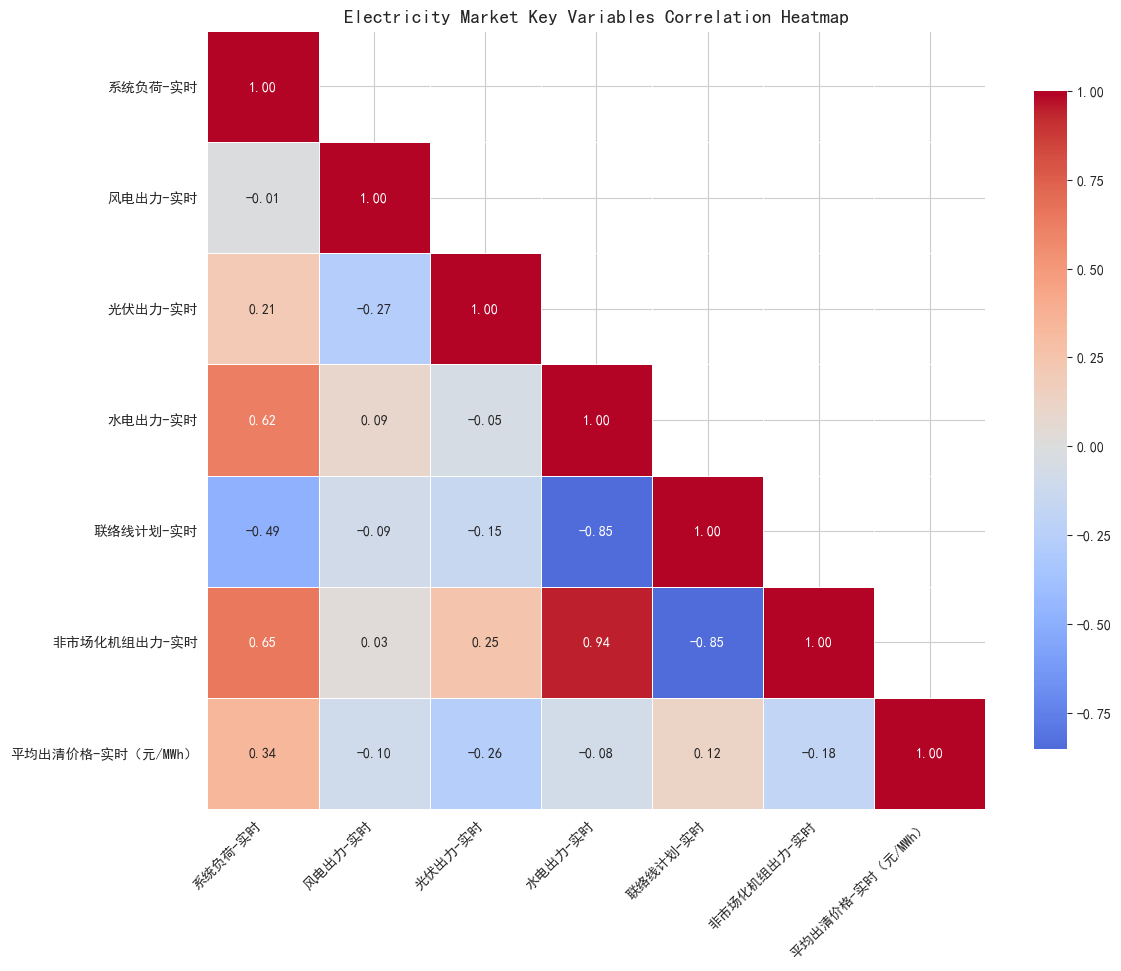

In [31]:
# 热力图 - 变量相关性分析
correlation_cols = ['系统负荷-实时', '风电出力-实时', '光伏出力-实时', 
                   '水电出力-实时', '联络线计划-实时', 
                   '非市场化机组出力-实时', '平均出清价格-实时（元/MWh）']

corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, 
            mask=mask,          
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True, 
            fmt='.2f', 
            cbar_kws={'shrink': .8},
            linewidths=0.5)      # 加网格线更清晰

plt.title('Electricity Market Key Variables Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')  # X轴标签旋转，避免重叠
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

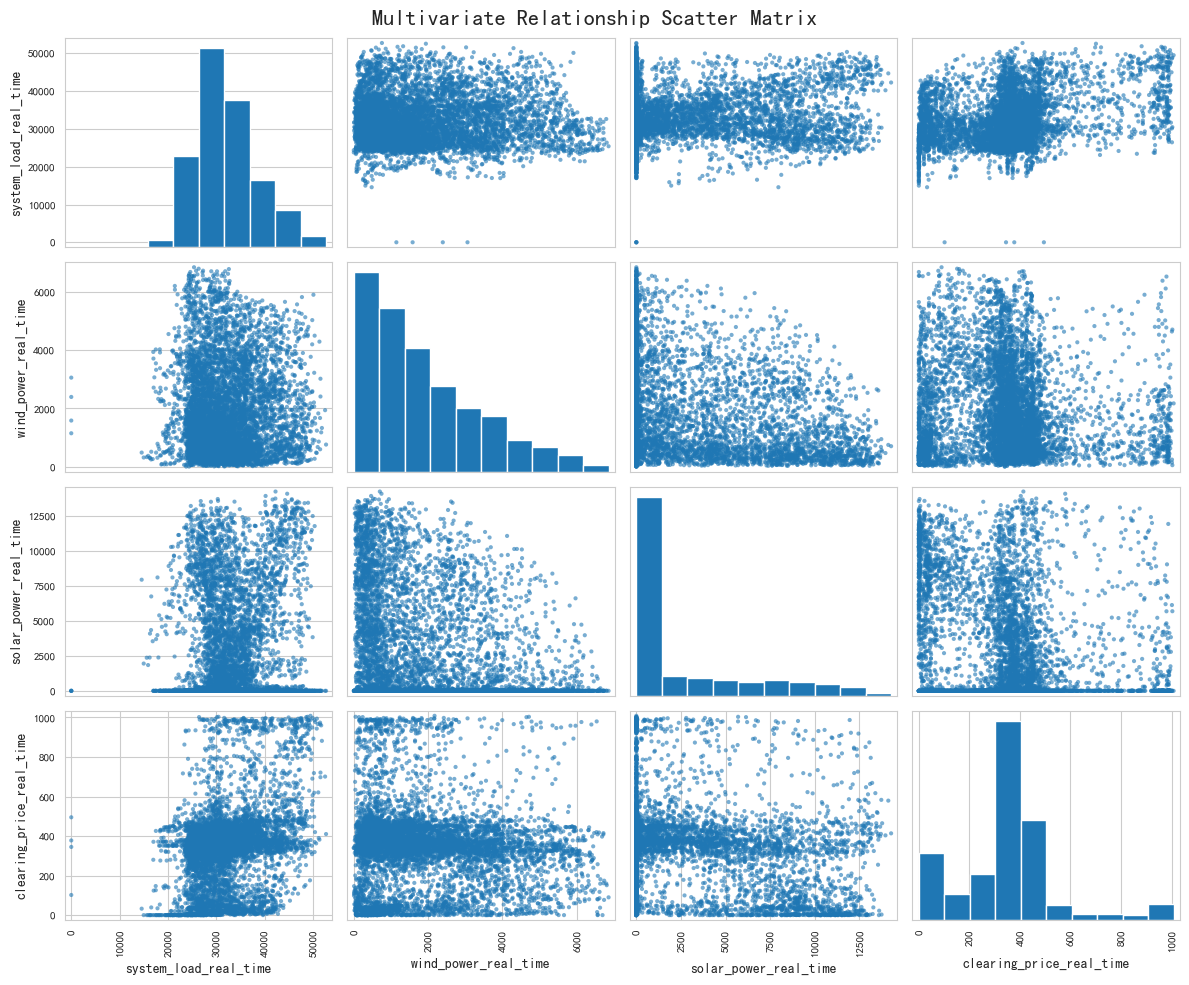

In [32]:
# 多变量散点图矩阵
# 选择关键变量进行散点图矩阵分析
scatter_cols = ['system_load_real_time', 'wind_power_real_time', 'solar_power_real_time', 'clearing_price_real_time']
scatter_df = df_en[scatter_cols].dropna()

from pandas.plotting import scatter_matrix

plt.figure(figsize=(12, 10))
scatter_matrix(scatter_df, alpha=0.6, figsize=(12, 10), diagonal='hist')
plt.suptitle('Multivariate Relationship Scatter Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 特征重要性分析

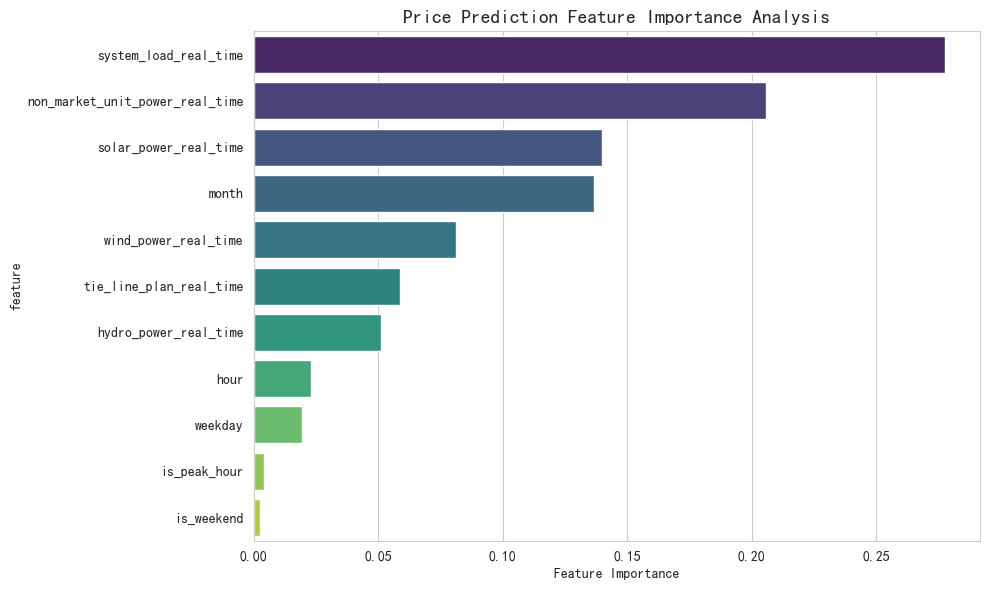

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 准备特征和目标变量
feature_cols = ['system_load_real_time', 'wind_power_real_time', 
                'solar_power_real_time', 'hydro_power_real_time',
                'tie_line_plan_real_time', 'non_market_unit_power_real_time',
                'hour', 'weekday', 'month', 'is_weekend', 'is_peak_hour']

# 同步清洗
xy = df_en[feature_cols + ['clearing_price_real_time']].dropna()
X = xy[feature_cols]
y = xy['clearing_price_real_time']

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 训练随机森林模型
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 特征重要性可视化
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Price Prediction Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

## 7. 异常值监测

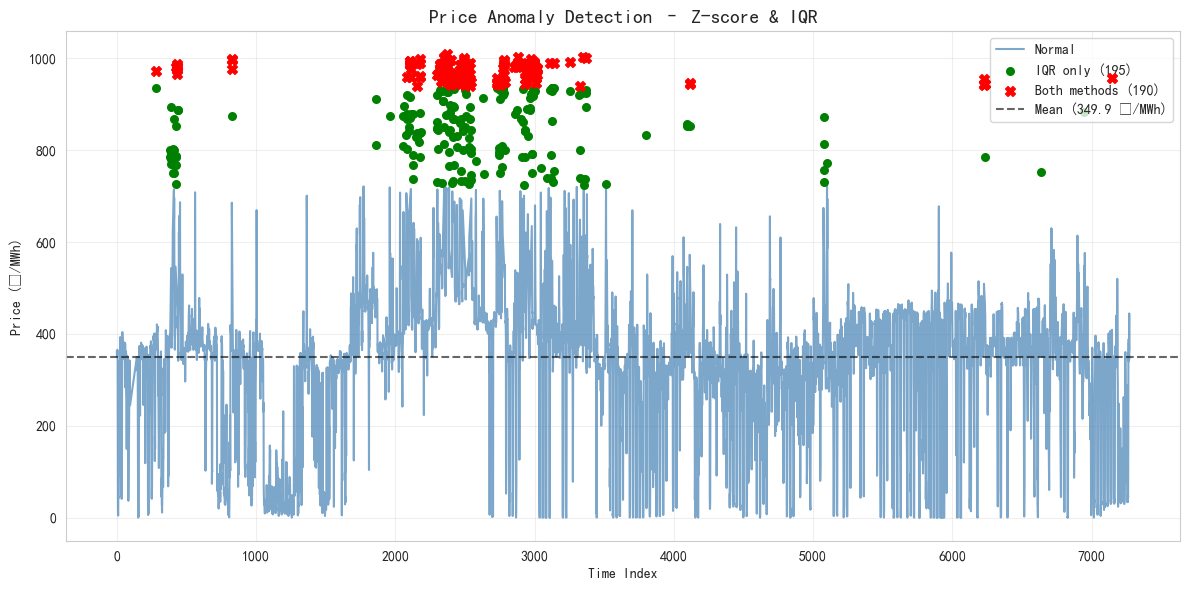

In [34]:
from scipy import stats

price_data = df_en['clearing_price_real_time'].dropna()

# ---------- Z-score ----------
z_scores = np.abs(stats.zscore(price_data))
z_thresh = 3
z_anom = price_data[z_scores > z_thresh]

# ---------- IQR ----------
q1 = price_data.quantile(0.25)
q3 = price_data.quantile(0.75)
iqr = q3 - q1
lower = q1 - 2 * iqr
upper = q3 + 2 * iqr
iqr_anom = price_data[(price_data < lower) | (price_data > upper)]

# ---------- 合并异常标签 ----------
anom_idx = set(z_anom.index) | set(iqr_anom.index)          # 并集
both_idx = set(z_anom.index) & set(iqr_anom.index)          # 交集
z_only   = set(z_anom.index) - both_idx
iqr_only = set(iqr_anom.index) - both_idx

# 为绘图准备
normal     = price_data[~price_data.index.isin(anom_idx)]
z_only_s   = price_data[price_data.index.isin(z_only)]
iqr_only_s = price_data[price_data.index.isin(iqr_only)]
both_s     = price_data[price_data.index.isin(both_idx)]

# ---------- 可视化 ----------
plt.figure(figsize=(12, 6))
plt.plot(normal.index, normal.values, alpha=0.7, label='Normal', color='steelblue')
if len(z_only_s):
    plt.scatter(z_only_s.index, z_only_s.values, color='orange', s=30,
                label=f'Z-score only ({len(z_only)})', zorder=5)
if len(iqr_only_s):
    plt.scatter(iqr_only_s.index, iqr_only_s.values, color='green', s=30,
                label=f'IQR only ({len(iqr_only)})', zorder=5)
if len(both_s):
    plt.scatter(both_s.index, both_s.values, color='red', s=50, marker='X',
                label=f'Both methods ({len(both_s)})', zorder=6)

plt.axhline(y=price_data.mean(), color='black', linestyle='--', alpha=0.6,
            label=f'Mean ({price_data.mean():.1f} ¥/MWh)')
plt.title('Price Anomaly Detection – Z-score & IQR', fontsize=14, fontweight='bold')
plt.xlabel('Time Index')
plt.ylabel('Price (¥/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()